In [1]:
import pandas as pd 

df = pd.read_csv('loanapproval.csv')
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [3]:
# Identifier les variables numériques et catégorielles

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns

print('variables numériques:', numerical_cols)

print('variables catégorielles:', categorical_cols)

variables numériques: Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')
variables catégorielles: Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')


In [4]:
#Affiher les valeurs manquantes 

df.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
#Calculer le pourcentage des valeus manquantes pour chaque colonnes

missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

Loan_ID              0.000000
Gender               2.117264
Married              0.488599
Dependents           2.442997
Education            0.000000
Self_Employed        5.211726
ApplicantIncome      0.000000
CoapplicantIncome    0.000000
LoanAmount           3.583062
Loan_Amount_Term     2.280130
Credit_History       8.143322
Property_Area        0.000000
Loan_Status          0.000000
dtype: float64


In [6]:
#Afficher uniquement les colonnes avec des valeurs manquantes 

columns_with_missing = missing_percentage[missing_percentage > 0]

print(columns_with_missing)

Gender              2.117264
Married             0.488599
Dependents          2.442997
Self_Employed       5.211726
LoanAmount          3.583062
Loan_Amount_Term    2.280130
Credit_History      8.143322
dtype: float64


In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [8]:
# Calculer le nombre total de demandes
total = len(df)

# Compter le nombre d'approbations ('Y')
approved = len(df[df['Loan_Status'] == 'Y'])

# Calculer le taux d'approbation
rate = (approved / total) * 100

# Afficher le résultat
print(f"Le taux d'approbation global est de {rate:.2f}%")



Le taux d'approbation global est de 68.73%


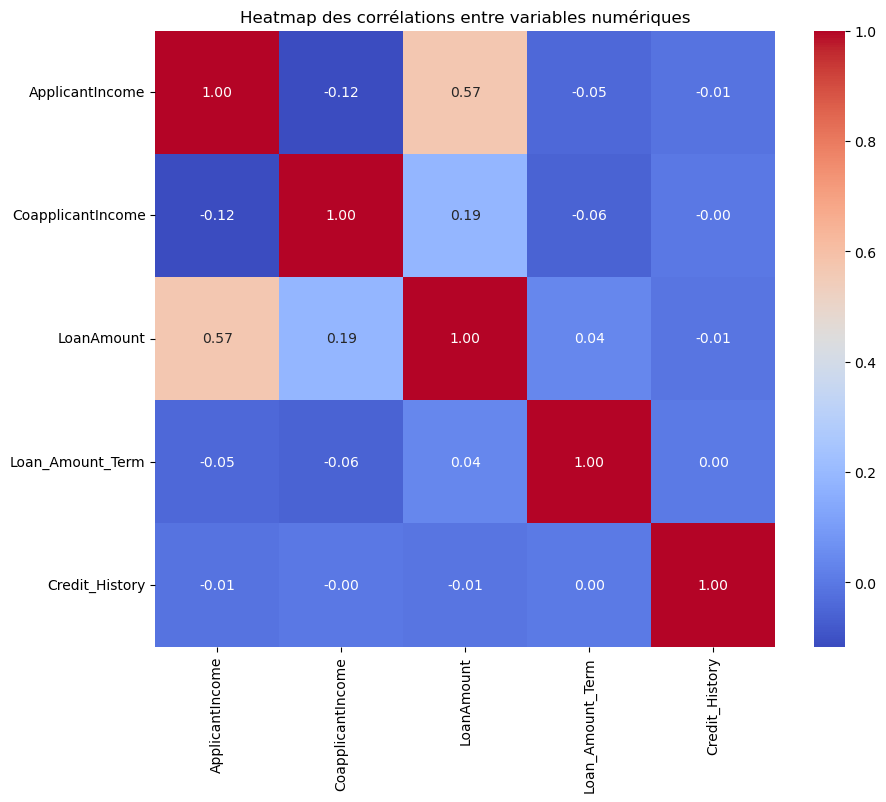

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélectionner uniquement les colonnes numériques
numerical_df = df.select_dtypes(include=['int64', 'float64'])

# Calculer la matrice de corrélation
corr_matrix = numerical_df.corr()

# Créer la heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap des corrélations entre variables numériques')
plt.show()

Taux d'approbation par niveau d'éducation (%):
Loan_Status           N          Y
Education                         
Graduate      29.166667  70.833333
Not Graduate  38.805970  61.194030


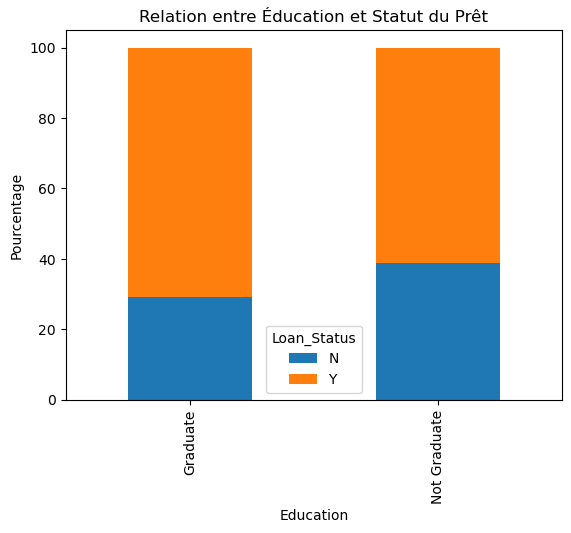

In [10]:
# Créer une table de contingence
crosstab = pd.crosstab(df['Education'], df['Loan_Status'], normalize='index') * 100

# Afficher la table
print("Taux d'approbation par niveau d'éducation (%):")
print(crosstab)

# Visualiser avec un barplot
crosstab.plot(kind='bar', stacked=True)
plt.title('Relation entre Éducation et Statut du Prêt')
plt.ylabel('Pourcentage')
plt.show()

Taux d'approbation par statut marital (%):
Loan_Status          N          Y
Married                          
No           37.089202  62.910798
Yes          28.391960  71.608040


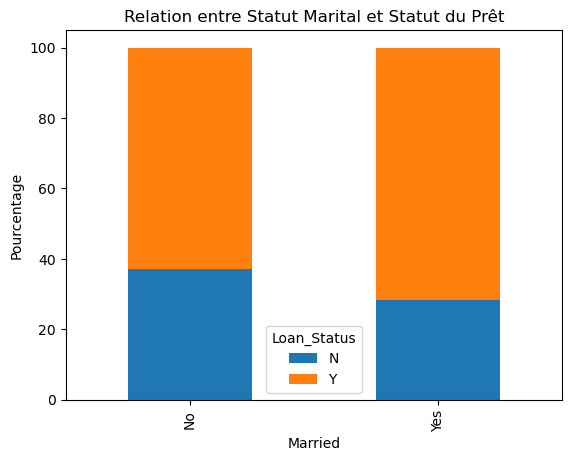

In [11]:
#Créer une table de contingence (pourcentages par ligne)
crosstab = pd.crosstab(df['Married'], df['Loan_Status'], normalize='index') * 100

# Afficher la table
print("Taux d'approbation par statut marital (%):")
print(crosstab)

# Visualiser avec un barplot
crosstab.plot(kind='bar', stacked=True)
plt.title('Relation entre Statut Marital et Statut du Prêt')
plt.ylabel('Pourcentage')
plt.show()



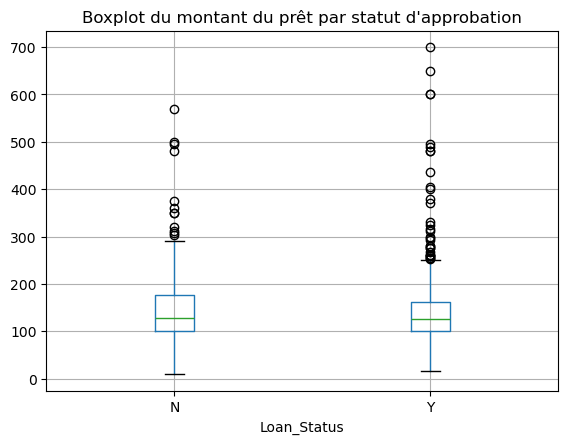

In [12]:
# Créer le boxplot
df.boxplot(column='LoanAmount', by='Loan_Status')

# Afficher le graphique
plt.title('Boxplot du montant du prêt par statut d\'approbation')
plt.suptitle('')  # Supprimer le titre automatique
plt.show()

1. 

Les colonnes avec le plus de valeurs manquantes sont :
Credit_History : 50 manquantes
Self_Employed : 32 manquantes
LoanAmount : 22 manquantes
Dependents : 15 manquantes
Loan_Amount_Term : 14 manquantes
Gender : 13 manquantes
Married : 3 manquantes
Selon moi, ces manques pourraient s'expliquer par plusieurs raisons : pour Credit_History, il s'agit peut-être de données sensibles ou non disponibles pour certains demandeurs par exemple une absence d'historique de crédit.
Self_Employed pourrait être omis si la personne n'est pas salariée ou si le formulaire permet de sauter cette question. 
LoanAmount et Loan_Amount_Term pourraient résulter d'erreurs de saisie ou de demandes incomplètes.
Gender et Married sont des infos personnelles qui pourraient être non déclarées pour des raisons de confidentialité.

 
2. 

Le taux d'approbation global est de 68.73 % environ 69 % de "Y" pour approuvé, contre 31 % de "N" pour rejeté. 
Cela ne me semble pas équilibré car il y a une majorité claire d'approbations.
Pour l'entraînement d'un modèle de machine learning cela implique un risque de biais vers la classe majoritaire c'est à dire que le modèle pourrait prédire "approuvé" par défaut et avoir une accuracy élevée sans être vraiment performant sur les rejets.
Il faudrait utiliser des techniques comme le suréchantillonnage SMOTE pour créer des exemples minoritaires, le sous-échantillonnage des poids de classes ou des métriques adaptées comme le F1-score ou l'AUC-ROC au lieu de l'accuracy simple.

3. 

Oui, il y a une légère différence :
Femmes : 66.96 % approuvé (33.04 % rejeté)
Hommes : 69.33 % approuvé (30.67 % rejeté)

La différence est d'environ 2.37 points de pourcentage en faveur des hommes. 

Je pense que cela pourrait refléter des biais sociétaux ou structurels comme des disparités de revenus les hommes pourraient avoir des salaires plus élevés en moyenne influençant l'approbation. 


4. 

Parmi les variables numériques (ApplicantIncome, CoapplicantIncome, LoanAmount, Loan_Amount_Term, Credit_History), les plus corrélées sont :

LoanAmount et ApplicantIncome : corrélation de 0.57 (positive modérée)
Les autres corrélations sont faibles (inférieures à 0.5 en valeur absolue)

On pourrait utiliser cette information pour du feature engineering 

5. 

Un histogramme des revenus (ApplicantIncome) pour voir la distribution et détecter des outliers 

Un scatterplot de LoanAmount vs ApplicantIncome coloré par Loan_Status, pour visualiser comment le montant du prêt varie avec le revenu et l'approbation

Un barplot du taux d'approbation par Property_Area (Urban, Semiurban, Rural) pour explorer les différences géographiques

Un boxplot de LoanAmount par Dependents pour voir l'impact du nombre de dépendants




In [13]:
print(f"\n{'─'*55}")
print("VALEURS MANQUANTES")
print(f"{'─'*55}")

# Variables numériques imputation par la médiane
num_cols_with_na = ["LoanAmount", "Loan_Amount_Term", "Credit_History"]
for col in num_cols_with_na:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)
    print(f"  ✔ {col:<22} imputation médiane = {median_val}")

# Variables catégorielles imputation par le mode
cat_cols_with_na = ["Gender", "Married", "Dependents", "Self_Employed"]
for col in cat_cols_with_na:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)
    print(f"  ✔ {col:<22} imputation mode   = {mode_val}")

print(f"\n  Valeurs manquantes restantes : {df.isnull().sum().sum()}")


───────────────────────────────────────────────────────
VALEURS MANQUANTES
───────────────────────────────────────────────────────
  ✔ LoanAmount             imputation médiane = 128.0
  ✔ Loan_Amount_Term       imputation médiane = 360.0
  ✔ Credit_History         imputation médiane = 1.0
  ✔ Gender                 imputation mode   = Male
  ✔ Married                imputation mode   = Yes
  ✔ Dependents             imputation mode   = 0
  ✔ Self_Employed          imputation mode   = No

  Valeurs manquantes restantes : 0


In [14]:
# Détection et traitement des outliers

print(f"\n{'─'*55}")
print("OUTLIERS (méthode IQR + capping)")
print(f"{'─'*55}")

numeric_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]

outlier_report = {}
for col in numeric_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = n_outliers

    # Capping (winsorisation)
    df[col] = df[col].clip(lower=lower, upper=upper)

    print(f"  ✔ {col:<22} bornes [{lower:,.0f} – {upper:,.0f}]  "
          f"→ {n_outliers} outliers cappés")




───────────────────────────────────────────────────────
OUTLIERS (méthode IQR + capping)
───────────────────────────────────────────────────────
  ✔ ApplicantIncome        bornes [-1,499 – 10,171]  → 50 outliers cappés
  ✔ CoapplicantIncome      bornes [-3,446 – 5,743]  → 18 outliers cappés
  ✔ LoanAmount             bornes [4 – 262]  → 41 outliers cappés


In [15]:
import numpy as np

# FEATURE ENGINEERING MÉTIER

print(f"\n{'─'*55}")
print("FEATURE ENGINEERING")
print(f"{'─'*55}")

# Revenu total du foyer
df["TotalIncome"] = df["ApplicantIncome"] + df["CoapplicantIncome"]
print("  ✔ TotalIncome            = ApplicantIncome + CoapplicantIncome")

# Ratio mensualité / revenu  (LoanAmount est en milliers)
df["EMI_Income_Ratio"] = (df["LoanAmount"] * 1000) / (
    df["Loan_Amount_Term"] * df["TotalIncome"].replace(0, np.nan)
)
df["EMI_Income_Ratio"] = df["EMI_Income_Ratio"].fillna(df["EMI_Income_Ratio"].median())
print("  ✔ EMI_Income_Ratio       = (LoanAmount×1000) / (Term × TotalIncome)")

# Log-transform pour réduire la skewness
for col in ["ApplicantIncome", "CoapplicantIncome", "LoanAmount", "TotalIncome"]:
    df[f"Log_{col}"] = np.log1p(df[col])
    print(f"  ✔ Log_{col}")

# Nombre de dépendants (nettoyage du "3+" → 3)
df["Dependents"] = df["Dependents"].replace("3+", "3").fillna("0").astype(int)
print("  ✔ Dependents             '3+' → 3  (converti en int)")

# Indicateur : co-emprunteur présent
df["Has_Coapplicant"] = (df["CoapplicantIncome"] > 0).astype(int)
print("  ✔ Has_Coapplicant        = 1 si CoapplicantIncome > 0")

# Indicateur : LoanAmount élevé (> médiane)
loan_median = df["LoanAmount"].median()
df["HighLoan"] = (df["LoanAmount"] > loan_median).astype(int)
print(f"  ✔ HighLoan               = 1 si LoanAmount > {loan_median:.0f} (médiane)")



───────────────────────────────────────────────────────
FEATURE ENGINEERING
───────────────────────────────────────────────────────
  ✔ TotalIncome            = ApplicantIncome + CoapplicantIncome
  ✔ EMI_Income_Ratio       = (LoanAmount×1000) / (Term × TotalIncome)
  ✔ Log_ApplicantIncome
  ✔ Log_CoapplicantIncome
  ✔ Log_LoanAmount
  ✔ Log_TotalIncome
  ✔ Dependents             '3+' → 3  (converti en int)
  ✔ Has_Coapplicant        = 1 si CoapplicantIncome > 0
  ✔ HighLoan               = 1 si LoanAmount > 128 (médiane)


In [16]:
# 4. ENCODAGE DES VARIABLES CATÉGORIELLES

print(f"\n{'─'*55}")
print("ENCODAGE")
print(f"{'─'*55}")

# Encodage binaire (Label Encoding)
binary_map = {
    "Gender":        {"Male": 1, "Female": 0},
    "Married":       {"Yes": 1, "No": 0},
    "Education":     {"Graduate": 1, "Not Graduate": 0},
    "Self_Employed": {"Yes": 1, "No": 0},
    "Loan_Status":   {"Y": 1, "N": 0},
}
for col, mapping in binary_map.items():
    df[col] = df[col].map(mapping)
    print(f"  ✔ {col:<22} label encoding  → {mapping}")

# One-Hot Encoding pour Property_Area (3 catégories)
df = pd.get_dummies(df, columns=["Property_Area"], prefix="Area", drop_first=False)
area_cols = [c for c in df.columns if c.startswith("Area_")]
print(f"  ✔ Property_Area          one-hot  → {area_cols}")

# Suppression des colonnes inutiles
df.drop(columns=["Loan_ID"], inplace=True)
print("  ✔ Loan_ID                supprimé (identifiant non prédictif)")

# Cast booléens (pandas >= 1.0) en int
bool_cols = df.select_dtypes(include="bool").columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)




───────────────────────────────────────────────────────
ENCODAGE
───────────────────────────────────────────────────────
  ✔ Gender                 label encoding  → {'Male': 1, 'Female': 0}
  ✔ Married                label encoding  → {'Yes': 1, 'No': 0}
  ✔ Education              label encoding  → {'Graduate': 1, 'Not Graduate': 0}
  ✔ Self_Employed          label encoding  → {'Yes': 1, 'No': 0}
  ✔ Loan_Status            label encoding  → {'Y': 1, 'N': 0}
  ✔ Property_Area          one-hot  → ['Area_Rural', 'Area_Semiurban', 'Area_Urban']
  ✔ Loan_ID                supprimé (identifiant non prédictif)


In [17]:
# Sauvegarder le nouveau dataset 
df.to_csv("loancleaned.csv")

 

1. 
Car la médiane est robuste, c'est la valeur centrale qui partage la distribution en deux moitiés peu importe ce qui se passe aux extrêmes. 
En imputant avec la médiane, on injecte une valeur plausible sans biaiser la distribution existante

2. 
Label Encoding remplace chaque catégorie par un entier Male : 1, Female : 0 C'est adapté aux variables binaires ou ordinales tandis que One-Hot Encoding crée une colonne booléenne par catégorie

3. 
Pour le guidage du modèle et le signal métier concentré. 
le feature engineering c'est aussi pour injecter de la connaissance du domaine là où les données seules sont insuffisantes

4. 
Le capping consiste à remplacer toute valeur dépassant une borne haute (ou basse) par cette borne elle-même, plutôt que de supprimer la ligne